# Time delay-cosmography simulations

This notebook requires standard python libraries and the publicly available packages on github:

- lenstronomy (https://github.com/lenstronomy/lenstronomy) (pip install lenstronomy)

For further information, please get in touch with the lenstronomy developers.

In [1]:
# import of standard python libraries
import numpy as np
import os
import time
import corner
import astropy.io.fits as pyfits

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
%matplotlib inline

# make sure lenstronomy is installed, otherwise install the latest pip version
try:
    import lenstronomy
except:
    !pip install lenstronomy

# lenstronomy imports
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
from lenstronomy.LightModel.light_model import LightModel
from lenstronomy.PointSource.point_source import PointSource
from lenstronomy.ImSim.image_model import ImageModel
import lenstronomy.Util.param_util as param_util
import lenstronomy.Util.simulation_util as sim_util
import lenstronomy.Util.image_util as image_util
from lenstronomy.Util import kernel_util
from lenstronomy.Data.imaging_data import ImageData
from lenstronomy.Data.psf import PSF

## simulation choices

In [2]:

# define lens configuration and cosmology (not for lens modelling)
z_lens = 0.5
z_source = 1.5
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=70, Om0=0.3, Ob0=0.)


# import PSF file (only if you want the TinyTim PSF model, otherwise using a Gaussian PSF)
#path = os.getcwd()
#dirpath, _ = os.path.split(path)
#module_path, _ = os.path.split(dirpath)
#psf_filename = os.path.join(module_path, 'Data/PSF_TinyTim/psf_example.fits')
#kernel = pyfits.getdata(psf_filename)

#plt.matshow(np.log10(kernel))
#plt.show()

    
# data specifics
sigma_bkg = .05  #  background noise per pixel (Gaussian)
exp_time = 100.  #  exposure time (arbitrary units, flux per pixel is in units #photons/exp_time unit)
numPix = 100  #  cutout pixel size
deltaPix = 0.05  #  pixel size in arcsec (area per pixel = deltaPix**2)
fwhm = 0.1  # full width half max of PSF (only valid when psf_type='gaussian')
psf_type = 'GAUSSIAN'  # 'GAUSSIAN', 'PIXEL', 'NONE'
kernel_size = 91

#kernel_cut = kernel_util.cut_psf(kernel, kernel_size)

# initial input simulation

# generate the coordinate grid and image properties
kwargs_data = sim_util.data_configure_simple(numPix, deltaPix, exp_time, sigma_bkg)
data_class = ImageData(**kwargs_data)
# generate the psf variables

kwargs_psf = {'psf_type': psf_type, 'pixel_size': deltaPix, 'fwhm': fwhm}
#kwargs_psf = sim_util.psf_configure_simple(psf_type=psf_type, fwhm=fwhm, kernelsize=kernel_size, deltaPix=deltaPix, kernel=kernel)
psf_class = PSF(**kwargs_psf)

### Astrometric inaccuracies
PSF estimates are never perfect, and the modeling of the detailed flux at a small fraction of a pixel is prone to inaccuracies. If a point source has high signal-to-noise, the formal positional constraints might be over-constrained.

To mitigate this potential systematic, lenstronomy has the option of introducing offsets of the modeling of the point sources to the formal position of the images that are being used to compute the time delays. In that way, specific uncertainties in the astrometry can be captured regardless of the signal in the point source.

To enable this option:
1. set 'point_source_offset': True in kwargs_constraints (Param() class)
2. Define the new parameters (x- and y- offsets for all images) as part of kwargs_special named 'delta_x_image' and 'delta_y_image'
3. Define a prior/constraint of the offset parameter based on your astrometric precison. You can do that with Gaussian priors.


In [ ]:
astrometry_sigma = 0.001  # floor in the astrometric posiiton of the point sources due to calibrations and PSF uncertainties
if astrometry_sigma > 0:
    point_source_offset = True
else:
    point_source_offset = False

/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_44278/4039995877.py:77: RuntimeWarning: invalid value encountered in log10
  im = ax.matshow(np.log10(image_sim), origin='lower', vmin=v_min, vmax=v_max, cmap=cmap, extent=[0, 1, 0, 1])


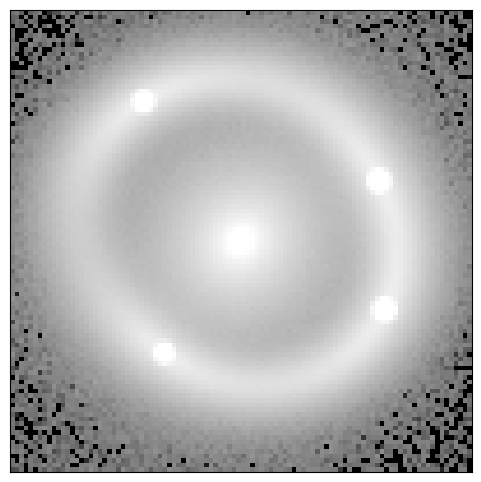

In [3]:
# lensing quantities
gamma1, gamma2 = param_util.shear_polar2cartesian(phi=-0.5, gamma=0.06)
kwargs_shear = {'gamma1': gamma1, 'gamma2': gamma2}  # shear values
kwargs_spemd = {'theta_E': 1.66, 'gamma': 1.98, 'center_x': 0.0, 'center_y': 0.0, 'e1': 0.05, 'e2': 0.05}  # parameters of the deflector lens model

# the lens model is a supperposition of an elliptical lens model with external shear
lens_model_list = ['EPL', 'SHEAR']
kwargs_lens = [kwargs_spemd, kwargs_shear]
lens_model_class = LensModel(lens_model_list=lens_model_list, z_lens=z_lens, z_source=z_source, cosmo=cosmo)

# choice of source type
source_type = 'SERSIC'  # 'SERSIC' or 'SHAPELETS'

source_x = 0.
source_y = 0.1


# Sersic parameters in the initial simulation
phi_G, q = 0.5, 0.8
e1, e2 = param_util.phi_q2_ellipticity(phi_G, q)
kwargs_sersic_source = {'amp': 4000, 'R_sersic': 0.2, 'n_sersic': 1, 'e1': e1, 'e2': e2, 'center_x': source_x, 'center_y': source_y}
#kwargs_else = {'sourcePos_x': source_x, 'sourcePos_y': source_y, 'quasar_amp': 400., 'gamma1_foreground': 0.0, 'gamma2_foreground':-0.0}
source_model_list = ['SERSIC_ELLIPSE']
kwargs_source = [kwargs_sersic_source]
source_model_class = LightModel(light_model_list=source_model_list)


# lens light model
phi_G, q = 0.9, 0.9
e1, e2 = param_util.phi_q2_ellipticity(phi_G, q)
kwargs_sersic_lens = {'amp': 8000, 'R_sersic': 0.4, 'n_sersic': 2., 'e1': e1, 'e2': e2, 'center_x': 0.0, 'center_y': 0}
lens_light_model_list = ['SERSIC_ELLIPSE']
kwargs_lens_light = [kwargs_sersic_lens]
lens_light_model_class = LightModel(light_model_list=lens_light_model_list)

lensEquationSolver = LensEquationSolver(lens_model_class)
x_image, y_image = lensEquationSolver.findBrightImage(source_x, source_y, kwargs_lens, numImages=4,
                                                      min_distance=deltaPix, search_window=numPix * deltaPix)
mag = lens_model_class.magnification(x_image, y_image, kwargs=kwargs_lens)
kwargs_ps = [{'ra_image': x_image, 'dec_image': y_image,
                           'point_amp': np.abs(mag)*1000}]  # quasar point source position in the source plane and intrinsic brightness
point_source_list = ['LENSED_POSITION']
point_source_class = PointSource(point_source_type_list=point_source_list, fixed_magnification_list=[False])

kwargs_numerics = {'supersampling_factor': 1}

imageModel = ImageModel(data_class, psf_class, lens_model_class, source_model_class,
                                lens_light_model_class, point_source_class, kwargs_numerics=kwargs_numerics)

# generate image
image_sim = imageModel.image(kwargs_lens, kwargs_source, kwargs_lens_light, kwargs_ps)
poisson = image_util.add_poisson(image_sim, exp_time=exp_time)
bkg = image_util.add_background(image_sim, sigma_bkd=sigma_bkg)
image_sim = image_sim + bkg + poisson

data_class.update_data(image_sim)
kwargs_data['image_data'] = image_sim


kwargs_model = {'lens_model_list': lens_model_list, 
                 'lens_light_model_list': lens_light_model_list,
                 'source_light_model_list': source_model_list,
                'point_source_model_list': point_source_list,
                 }

# display the initial simulated image
cmap_string = 'gray'
cmap = plt.get_cmap(cmap_string)
cmap.set_bad(color='k', alpha=1.)
cmap.set_under('k')

v_min = -4
v_max = 2

f, axes = plt.subplots(1, 1, figsize=(6, 6), sharex=False, sharey=False)
ax = axes
im = ax.matshow(np.log10(image_sim), origin='lower', vmin=v_min, vmax=v_max, cmap=cmap, extent=[0, 1, 0, 1])
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
ax.autoscale(False)
plt.show()

## time delays
time delays are defined in **lenstronomy** as the difference in light travel path relative to a straight line. Negative values correspond to earlier arrival times. The units are in days.

In [4]:
from lenstronomy.Analysis.td_cosmography import TDCosmography
td_cosmo = TDCosmography(z_lens, z_source, kwargs_model, cosmo_fiducial=cosmo)

# time delays, the unit [days] is matched when the lensing angles are in arcsec
t_days = td_cosmo.time_delays(kwargs_lens, kwargs_ps, kappa_ext=0)
print("the time delays for the images at position ", kwargs_ps[0]['ra_image'], kwargs_ps[0]['dec_image'], "are: ", t_days)

# relative delays (observable). The convention is relative to the first image
dt_days =  t_days[1:] - t_days[0]
# and errors can be assigned to the measured relative delays (full covariance matrix not yet implemented)
dt_sigma = [3, 5, 10]  # Gaussian errors
# and here a realisation of the measurement with the quoted error bars
dt_measured = np.random.normal(dt_days, dt_sigma)
print("the measured relative delays are: ", dt_measured)

the time delays for the images at position  [-1.0524586   1.55743121  1.49559537 -0.82778093] [ 1.51726795 -0.73816201  0.65337218 -1.21355168] are:  [-147.04064605 -124.51077068 -120.74673805 -101.64799033]
the measured relative delays are:  [25.41013582 26.52364294 43.80267982]


## kinematics
Kinematics can provide important complementary information about the lens to constrain cosmography

In [5]:
# observational conditions of the spectroscopic campagne
R_slit = 1. # slit length in arcsec
dR_slit = 1.  # slit width in arcsec
psf_fwhm = 0.7  # Full width at half maximum of the PSF

kwargs_aperture = {'aperture_type': 'slit', 'length': R_slit, 'width': dR_slit, 'center_ra': 0.05, 'center_dec': 0, 'angle': 0}
anisotropy_model = 'OM'
aperture_type = 'slit'

kwargs_numerics_galkin = {'interpol_grid_num': 1000,  # numerical interpolation, should converge -> infinity
                          'log_integration': True,  # log or linear interpolation of surface brightness and mass models
                           'max_integrate': 100, 'min_integrate': 0.001}  # lower/upper bound of numerical integrals

r_ani = 1.
r_eff = 0.2
kwargs_anisotropy = {'r_ani': r_ani}
kwargs_seeing = {'psf_type': 'GAUSSIAN', 'fwhm': psf_fwhm}

from lenstronomy.Analysis.kinematics_api import KinematicsAPI
kin_api = KinematicsAPI(z_lens, z_source, kwargs_model, cosmo=cosmo, 
                        lens_model_kinematics_bool=[True, False], light_model_kinematics_bool=[True], 
                        kwargs_aperture=kwargs_aperture, kwargs_seeing=kwargs_seeing, 
                        anisotropy_model=anisotropy_model, kwargs_numerics_galkin=kwargs_numerics_galkin,
                        sampling_number=10000,  # numerical ray-shooting, should converge -> infinity
                        Hernquist_approx=True)

vel_disp = kin_api.velocity_dispersion(kwargs_lens, kwargs_lens_light, kwargs_anisotropy, r_eff=r_eff, theta_E=None, kappa_ext=0)
print(vel_disp, 'velocity dispersion in km/s')

[269.12487431] velocity dispersion in km/s


## Model and parameter choices

In [6]:
# lens model choicers
fixed_lens = []
kwargs_lens_init = []
kwargs_lens_sigma = []
kwargs_lower_lens = []
kwargs_upper_lens = []

fixed_lens.append({}) 
kwargs_lens_init.append({'theta_E': 1.6, 'gamma': 2, 'center_x': 0.0, 'center_y': 0, 'e1': 0, 'e2': 0.})
#kwargs_lens_init.append(kwargs_spemd)
kwargs_lens_sigma.append({'theta_E': .2, 'e1': 0.1, 'e2': 0.1, 'gamma': 0.2, 'center_x': 0.1, 'center_y': 0.1})
kwargs_lower_lens.append({'theta_E': 0.01, 'e1': -0.5, 'e2': -0.5, 'gamma': 1.5, 'center_x': -10, 'center_y': -10})
kwargs_upper_lens.append({'theta_E': 10, 'e1': 0.5, 'e2': 0.5, 'gamma': 2.5, 'center_x': 10, 'center_y': 10})

fixed_lens.append({'ra_0': 0, 'dec_0': 0})
kwargs_lens_init.append({'gamma1': 0, 'gamma2': 0})
#kwargs_lens_init.append(kwargs_shear)
kwargs_lens_sigma.append({'gamma1': 0.1, 'gamma2': 0.1})
kwargs_lower_lens.append({'gamma1': -0.5, 'gamma2': -0.5})
kwargs_upper_lens.append({'gamma1': 0.5, 'gamma2': 0.5})

lens_params = [kwargs_lens_init, kwargs_lens_sigma, fixed_lens, kwargs_lower_lens, kwargs_upper_lens]

# lens light model choices
fixed_lens_light = []
kwargs_lens_light_init = []
kwargs_lens_light_sigma = []
kwargs_lower_lens_light = []
kwargs_upper_lens_light = []

fixed_lens_light.append({})
kwargs_lens_light_init.append({'R_sersic': 0.5, 'n_sersic': 1, 'e1': 0, 'e2': 0., 'center_x': 0, 'center_y': 0})
#kwargs_lens_light_init.append(kwargs_sersic_lens)
kwargs_lens_light_sigma.append({'n_sersic': 0.5, 'R_sersic': 0.1, 'e1': 0.1, 'e2': 0.1, 'center_x': 0.1, 'center_y': 0.1})
kwargs_lower_lens_light.append({'e1': -0.5, 'e2': -0.5, 'R_sersic': 0.01, 'n_sersic': 0.5, 'center_x': -10, 'center_y': -10})
kwargs_upper_lens_light.append({'e1': 0.5, 'e2': 0.5, 'R_sersic': 10, 'n_sersic': 8, 'center_x': 10, 'center_y': 10})

lens_light_params = [kwargs_lens_light_init, kwargs_lens_light_sigma, fixed_lens_light, kwargs_lower_lens_light, kwargs_upper_lens_light]


fixed_source = []
kwargs_source_init = []
kwargs_source_sigma = []
kwargs_lower_source = []
kwargs_upper_source = []

fixed_source.append({})
kwargs_source_init.append({'R_sersic': 0.1, 'n_sersic': 1, 'e1': 0, 'e2': 0., 'center_x': 0, 'center_y': 0})
#kwargs_source_init.append(kwargs_sersic_source)
kwargs_source_sigma.append({'n_sersic': 0.5, 'R_sersic': 0.05, 'e1': 0.1, 'e2': 0.1, 'center_x': 0.1, 'center_y': 0.1})
kwargs_lower_source.append({'e1': -0.5, 'e2': -0.5, 'R_sersic': 0.001, 'n_sersic': .5, 'center_x': -10, 'center_y': -10})
kwargs_upper_source.append({'e1': 0.5, 'e2': 0.5, 'R_sersic': 10, 'n_sersic': 5., 'center_x': 10, 'center_y': 10})

source_params = [kwargs_source_init, kwargs_source_sigma, fixed_source, kwargs_lower_source, kwargs_upper_source]


fixed_ps = [{}]
kwargs_ps_init = kwargs_ps
kwargs_ps_sigma = [{'ra_image': 0.01 * np.ones(len(x_image)), 'dec_image': 0.01 * np.ones(len(x_image))}]
kwargs_lower_ps = [{'ra_image': -10 * np.ones(len(x_image)), 'dec_image': -10 * np.ones(len(y_image))}]
kwargs_upper_ps = [{'ra_image': 10* np.ones(len(x_image)), 'dec_image': 10 * np.ones(len(y_image))}]

fixed_special = {}
kwargs_special_init = {'D_dt': 5000, "delta_x_image": np.zeros(len(x_image)), "delta_y_image": np.zeros(len(x_image))}
kwargs_special_sigma = {'D_dt': 10000, "delta_x_image": np.ones(len(x_image))*astrometry_sigma, "delta_y_image": np.ones(len(x_image))*astrometry_sigma}
kwargs_lower_special = {'D_dt': 0, "delta_x_image": -np.ones(len(x_image))*astrometry_sigma * 5, "delta_y_image": -np.ones(len(x_image))*astrometry_sigma * 5}
kwargs_upper_special = {'D_dt': 10000, "delta_x_image": np.ones(len(x_image))*astrometry_sigma * 5, "delta_y_image": np.ones(len(x_image))*astrometry_sigma * 5}
special_params = [kwargs_special_init, kwargs_special_sigma, fixed_special, kwargs_lower_special, kwargs_upper_special]

ps_params = [kwargs_ps_init, kwargs_ps_sigma, fixed_ps, kwargs_lower_ps, kwargs_upper_ps]

kwargs_params = {'lens_model': lens_params,
                'source_model': source_params,
                'lens_light_model': lens_light_params,
                'point_source_model': ps_params,
                'special': special_params}


In [7]:


# numerical options and fitting sequences

num_source_model = len(source_model_list)

kwargs_constraints = {'joint_source_with_point_source': [[0, 0]],
                      'num_point_source_list': [4],
                      'solver_type': 'PROFILE_SHEAR',  # 'PROFILE', 'PROFILE_SHEAR', 'ELLIPSE', 'CENTER'
                      'Ddt_sampling': True,
                      'point_source_offset': point_source_offset,  # modeling astrometric offset between true image position and the position of the point source in the image
                              }
if point_source_offset:
    prior_special = [["delta_x_image", np.zeros(len(x_image)), np.ones(len(x_image)) * astrometry_sigma]]
else:
    prior_special = None
# :param prior_special: list of [param_name, mean, 1-sigma priors]

kwargs_likelihood = {'check_bounds': True,
                     'force_no_add_image': False,
                     'source_marg': False,
                     'image_position_uncertainty': 0.004,
                     'source_position_tolerance': 0.001,
                     'time_delay_likelihood': True,
                     'prior_special': prior_special,
                             }

# TODO point source offset prior

image_band = [kwargs_data, kwargs_psf, kwargs_numerics]
multi_band_list = [image_band]
kwargs_data_joint = {'multi_band_list': multi_band_list, 'multi_band_type': 'multi-linear',
                    'time_delays_measured': dt_measured,
                    'time_delays_uncertainties': dt_sigma,}

from lenstronomy.Workflow.fitting_sequence import FittingSequence

mpi = False  # MPI possible, but not supported through that notebook.

from lenstronomy.Workflow.fitting_sequence import FittingSequence
fitting_seq = FittingSequence(kwargs_data_joint, kwargs_model, kwargs_constraints, kwargs_likelihood, kwargs_params)

fitting_kwargs_list = [['PSO', {'sigma_scale': .1, 'n_particles': 200, 'n_iterations': 200}],
        ['MCMC', {'n_burn': 100, 'n_run': 100, 'walkerRatio': 10, 'sigma_scale': .1}]
]

start_time = time.time()
chain_list = fitting_seq.fit_sequence(fitting_kwargs_list)
kwargs_result = fitting_seq.best_fit()
end_time = time.time()
print(end_time - start_time, 'total time needed for computation')
print('============ CONGRATULATION, YOUR JOB WAS SUCCESSFUL ================ ')

/Users/sibirrer/Software/lenstronomy/lenstronomy/Sampling/Likelihoods/position_likelihood.py:64: UserWarning: source_position_tolerance has been set but source_position_likelihood is False. 
In order to use the source_position_tolerance, set source_position_likelihood to True
  warnings.warn(
/Users/sibirrer/Software/lenstronomy/lenstronomy/LensModel/Solver/solver4point.py:115: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  x = scipy.optimize.fsolve(


Computing the PSO ...


  0%|                                                                                                                                                 | 0/200 [00:00<?, ?it/s]/Users/sibirrer/Software/lenstronomy/lenstronomy/LensModel/Solver/solver4point.py:115: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations.
  x = scipy.optimize.fsolve(
  2%|███▍                                                                                                                                     | 5/200 [00:16<09:26,  2.91s/it]/Users/sibirrer/Software/lenstronomy/lenstronomy/LensModel/Profiles/epl.py:300: RuntimeWarning: invalid value encountered in power
  alpha = 2 / (1 + q) * (b / R) ** t * R_omega
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [04:35<00:00,  1.38s/it]


Max iteration reached! Stopping.
-0.9934743821032725 reduced X^2 of best position
-4949.986108829556 log likelihood
9965 effective number of data points
[{'theta_E': 1.6596727962202151, 'gamma': 1.9770555835695545, 'e1': 0.05043299116780002, 'e2': 0.04894497230756699, 'center_x': 0.00018212912972584064, 'center_y': -0.00014282161097623844}, {'gamma1': 0.03285754811631822, 'gamma2': -0.050720391214051724, 'ra_0': 0, 'dec_0': 0}] lens result
[{'amp': 1, 'R_sersic': 0.19956158528170453, 'n_sersic': 1.0045563779199784, 'e1': 0.058959852870133445, 'e2': 0.09380505287773898, 'center_x': 0.00027769942599478736, 'center_y': 0.09936235726851664}] source result
[{'amp': 1, 'R_sersic': 0.40005354847939206, 'n_sersic': 2.0022529754191325, 'e1': -0.012242792554023467, 'e2': 0.05027015993483903, 'center_x': 6.0359777387418736e-05, 'center_y': -0.000367821668836169}] lens light result
[{'ra_image': array([-1.05274802,  1.55838926,  1.4953749 , -0.82719794]), 'dec_image': array([ 1.5163134 , -0.737619

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [06:17<00:00,  1.89s/it]

Computing the MCMC...
Number of walkers =  300
Burn-in iterations:  100
Sampling iterations (in current run): 200
379.5156829357147 time taken for MCMC sampling
654.8967351913452 total time needed for computation
============ CONGRATULATION, YOUR JOB WAS SUCCESSFUL ================ 


## analyse model output

/Users/sibirrer/Software/lenstronomy/lenstronomy/Plots/model_band_plot.py:161: RuntimeWarning: invalid value encountered in log10
  np.log10(self._data),


-0.9903963414791966 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  0.9903963414791968


/Users/sibirrer/Software/lenstronomy/lenstronomy/Plots/model_band_plot.py:1236: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()
/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_44278/663373263.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_44278/663373263.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
/Users/sibirrer/Software/lenstronomy/lenstronomy/Plots/model_band_plot.py:1186: RuntimeWarning: invalid value encountered in log10
  np.log10(self._data - model),
/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_44278/663373263.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


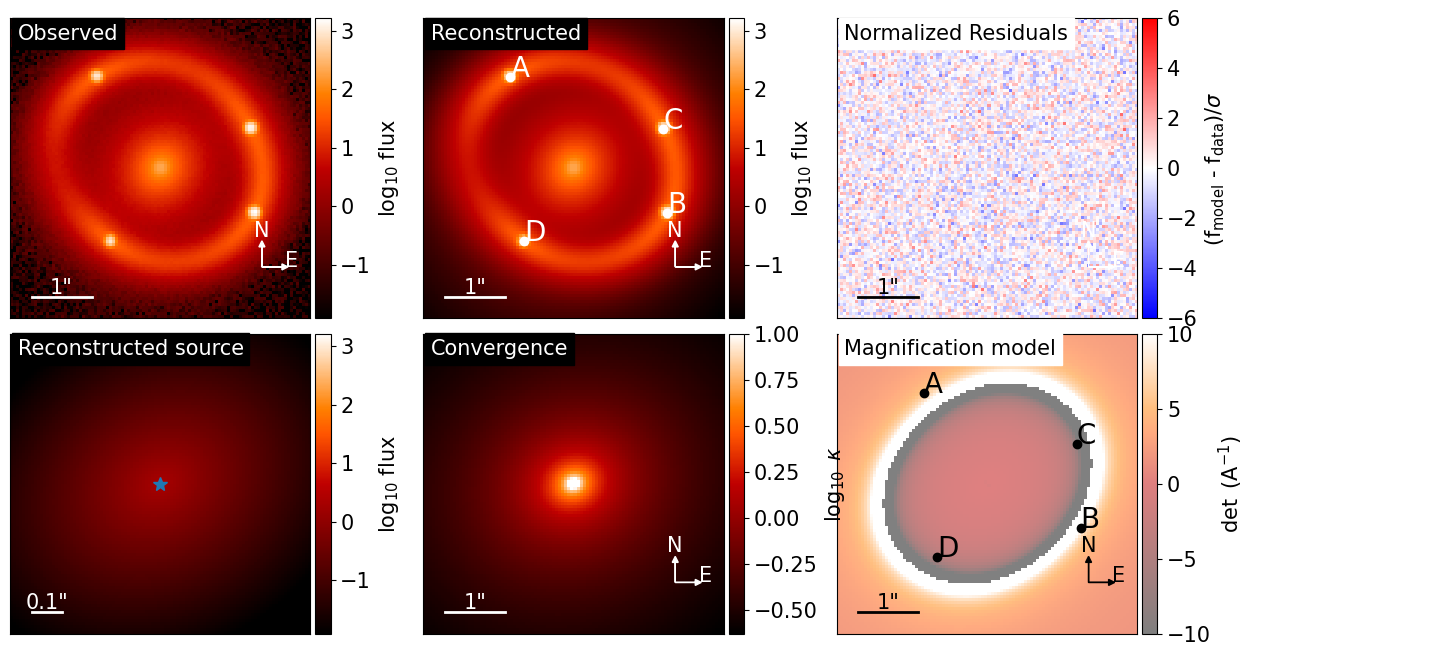

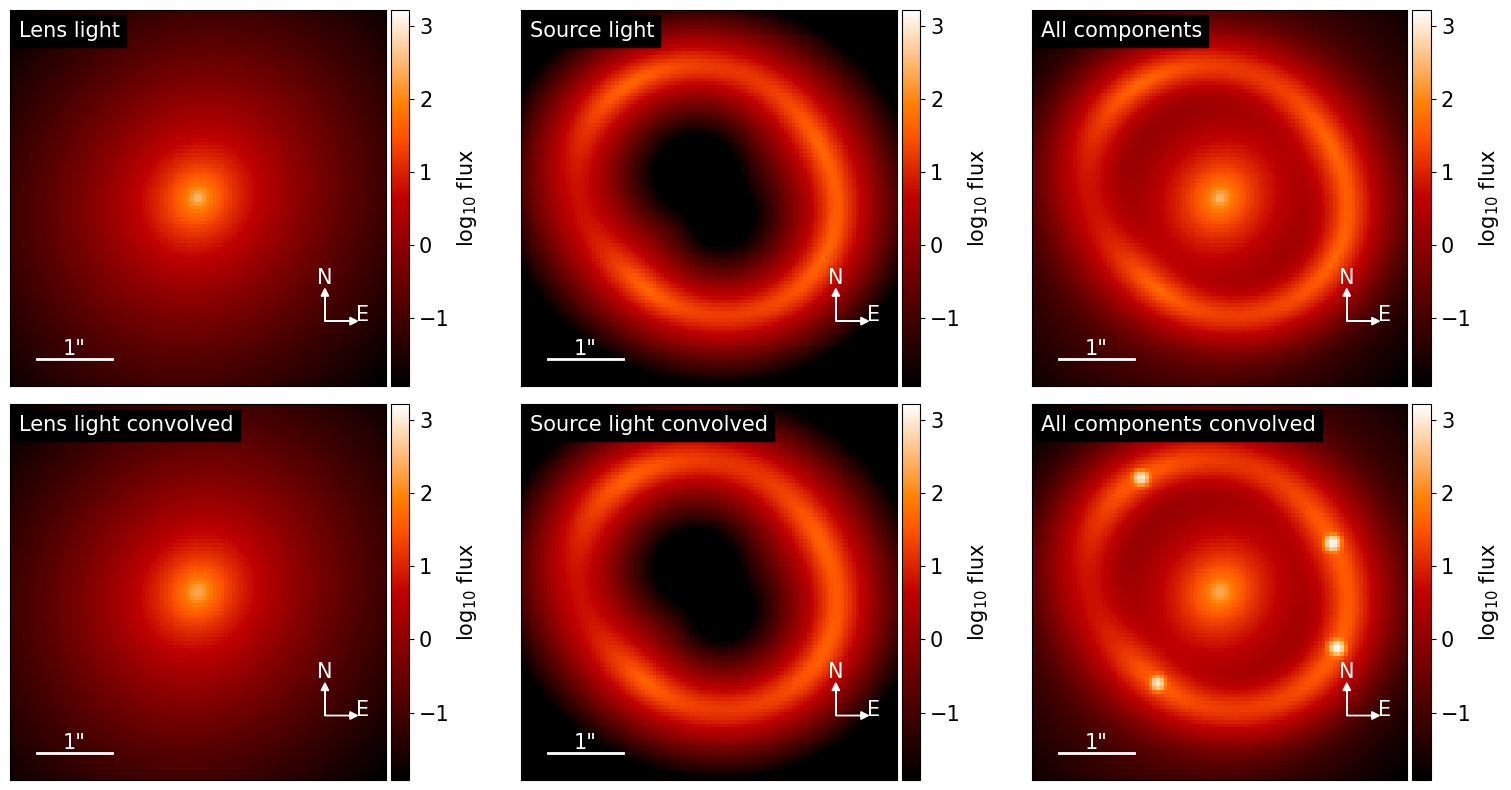

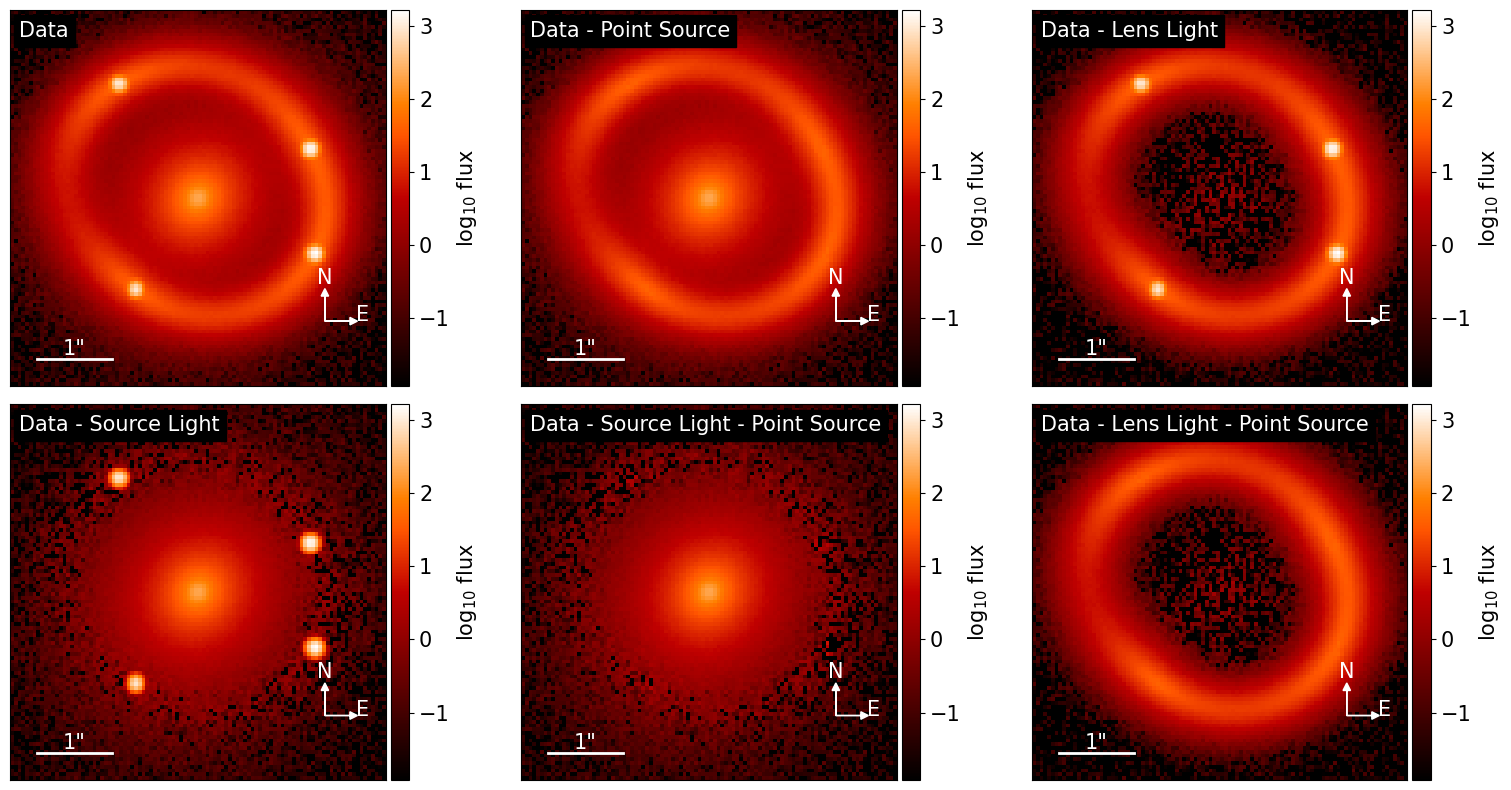

In [8]:
from lenstronomy.Plots import chain_plot
from lenstronomy.Plots.model_plot import ModelPlot

modelPlot = ModelPlot(multi_band_list, kwargs_model, kwargs_result, arrow_size=0.02, cmap_string="gist_heat")
    
f, axes = modelPlot.plot_main()
f.show()
f, axes = modelPlot.plot_separate()
f.show()
f, axes = modelPlot.plot_subtract_from_data_all()
f.show()


number of non-linear parameters in the MCMC process:  30
parameters in order:  ['gamma_lens0', 'gamma1_lens1', 'gamma2_lens1', 'R_sersic_source_light0', 'n_sersic_source_light0', 'e1_source_light0', 'e2_source_light0', 'R_sersic_lens_light0', 'n_sersic_lens_light0', 'e1_lens_light0', 'e2_lens_light0', 'center_x_lens_light0', 'center_y_lens_light0', 'ra_image', 'ra_image', 'ra_image', 'ra_image', 'dec_image', 'dec_image', 'dec_image', 'dec_image', 'D_dt', 'delta_x_image', 'delta_x_image', 'delta_x_image', 'delta_x_image', 'delta_y_image', 'delta_y_image', 'delta_y_image', 'delta_y_image']
number of evaluations in the MCMC process:  30000


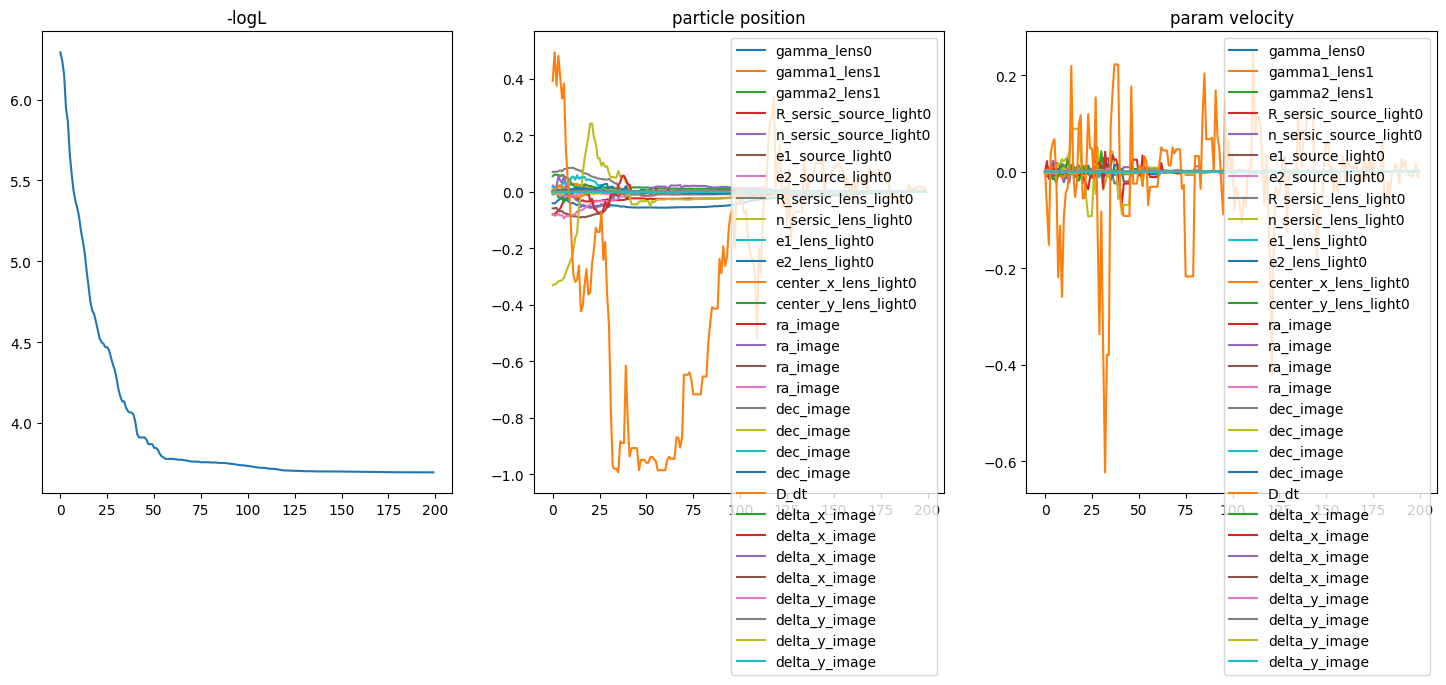

<Figure size 640x480 with 0 Axes>

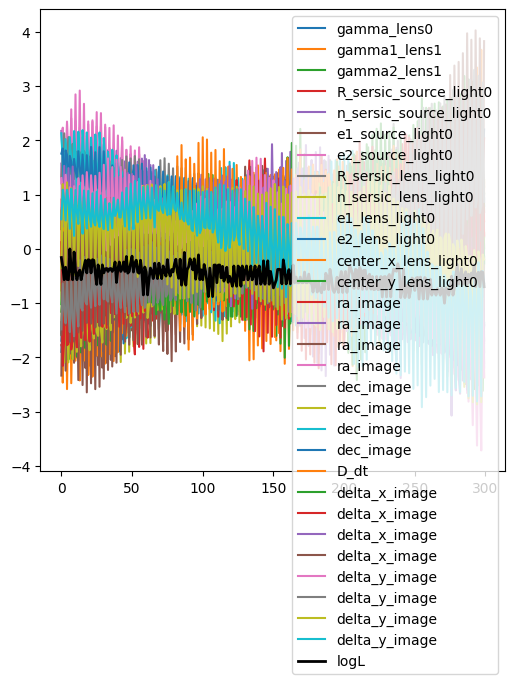

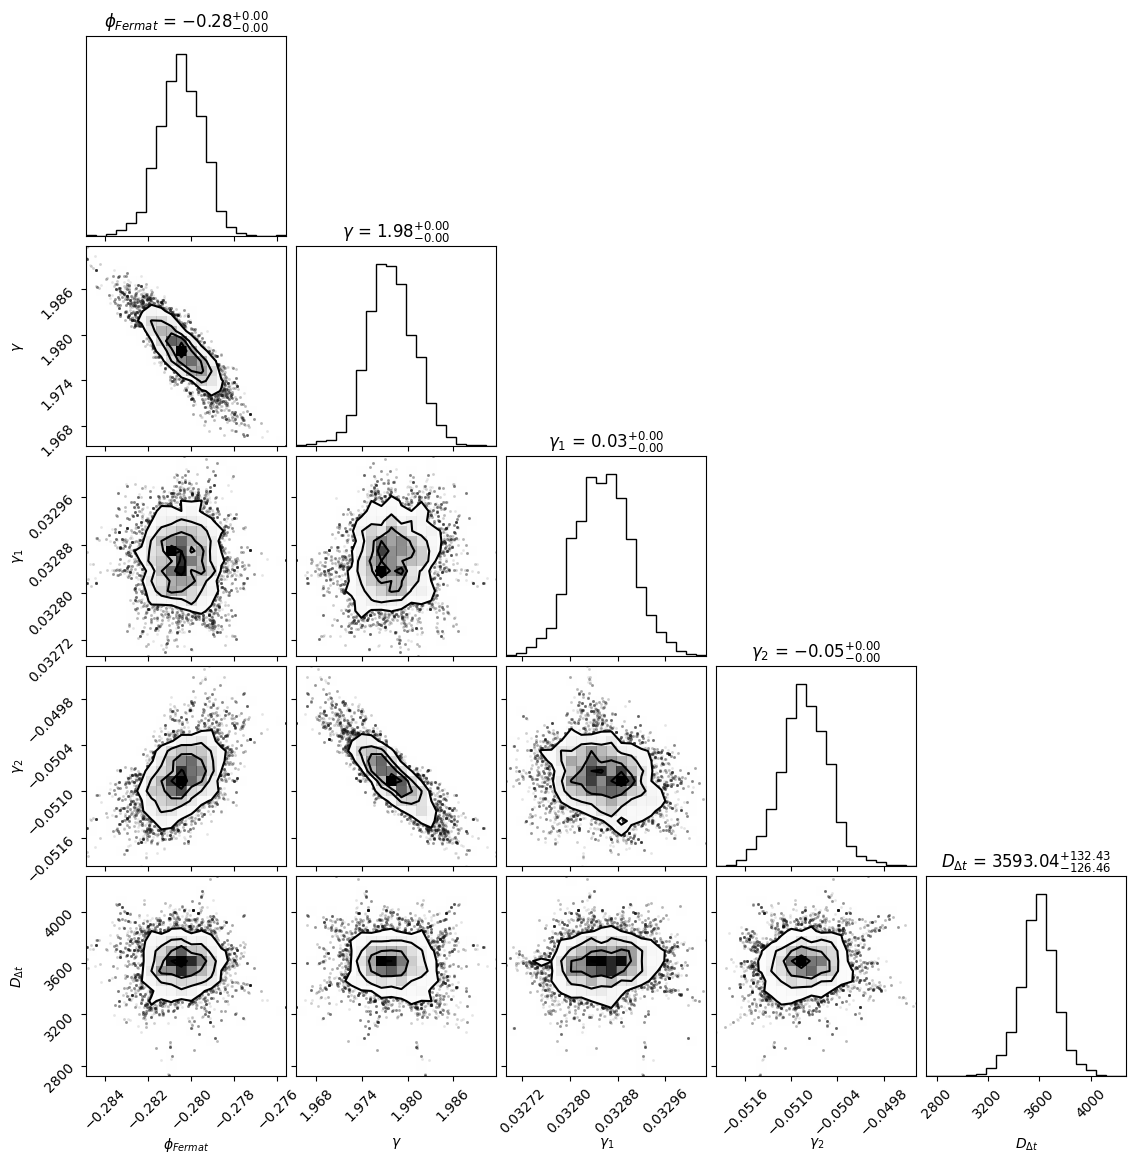

In [9]:
for i in range(len(chain_list)):
    chain_plot.plot_chain_list(chain_list, i)
    
sampler_type, samples_mcmc, param_mcmc, dist_mcmc  = chain_list[1]

print("number of non-linear parameters in the MCMC process: ", len(param_mcmc))
print("parameters in order: ", param_mcmc)
print("number of evaluations in the MCMC process: ", np.shape(samples_mcmc)[0])

# import the parameter handling class #
from lenstronomy.Sampling.parameters import Param
# make instance of parameter class with given model options, constraints and fixed parameters #

param = Param(kwargs_model, fixed_lens, fixed_source, fixed_lens_light, fixed_ps, fixed_special, 
              kwargs_lens_init=kwargs_result['kwargs_lens'], **kwargs_constraints)
# the number of non-linear parameters and their names #
num_param, param_list = param.num_param()


mcmc_new_list = []
labels_new = [r"$\phi_{Fermat}$", r"$\gamma$", r"$\gamma_1$", r"$\gamma_2$", r"$D_{\Delta t}$"]
for i in range(len(samples_mcmc)):
    # transform the parameter position of the MCMC chain in a lenstronomy convention with keyword arguments #
    kwargs_result = param.args2kwargs(samples_mcmc[i])
    D_dt = kwargs_result['kwargs_special']['D_dt']
    fermat_pot = td_cosmo.fermat_potential(kwargs_result['kwargs_lens'], kwargs_result['kwargs_ps'])
    delta_fermat_12 = fermat_pot[0] - fermat_pot[2]
    gamma = kwargs_result['kwargs_lens'][0]['gamma']
    gamma1, gamma2 = kwargs_result['kwargs_lens'][1]['gamma1'], kwargs_result['kwargs_lens'][1]['gamma2']
    mcmc_new_list.append([delta_fermat_12, gamma, gamma1, gamma2, D_dt])


plot = corner.corner(np.array(mcmc_new_list), labels=labels_new, show_titles=True)

In [10]:
from lenstronomy.Cosmo.lens_cosmo import LensCosmo
lensCosmo = LensCosmo(z_lens=z_lens, z_source=z_source, cosmo=cosmo)
print(lensCosmo.ddt)

3329.6653609254795
